Practice: train_test split, tfidf, model, fit, transform

In [278]:
#import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

In [279]:
#load the dataset
#df = pd.read_csv('SMSSpamCollection', delimiter='\t', header=None, names=['label', 'message'])
df = pd.read_csv(
    "SMSSpamCollection",
    delimiter="\t",
    header=None
)

In [280]:
df.head()

,0,1
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [281]:
# rename columns
df.columns = ["label","message"]

In [282]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [283]:
#understand the dataset
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [284]:
df[df["label"]=="spam"].head()

,label,message
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
5,spam,FreeMsg Hey there darling it's been 3 week's n...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...
11,spam,"SIX chances to win CASH! From 100 to 20,000 po..."


In [285]:
df[df["label"]=="ham"].head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
6,ham,Even my brother is not like to speak with me. ...


In [286]:
#separate X and y
X = df["message"]
y = df["label"]

In [287]:
#split the dataset into training and testing sets
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.25,
    random_state=42,
    stratify=y)

In [288]:
#convert text data into numerical features using TF-IDF vectorization
vectorizer = TfidfVectorizer()


In [289]:
#for training
X_train = vectorizer.fit_transform(X_train_raw)

In [290]:
#For testing
X_test = vectorizer.transform(X_test_raw)

In [291]:
#Train a logistic regression model
classifier = LogisticRegression()

In [292]:
#Train
classifier.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

Practise cross validation

In [293]:
#import cross_val_score for cross-validation
from sklearn.model_selection import cross_val_score


In [294]:
# Perform 5-fold cross-validation
scores = cross_val_score(
    classifier,
    X_train,
    y_train,
    cv=5
)

In [295]:
print(scores)
print(scores.mean())

[0.96411483 0.95813397 0.96172249 0.93779904 0.95568862]
0.9554917915365442


End of cross validation section

In [296]:
#Predict the labels for the test set
predictions = classifier.predict(X_test)

In [297]:
predictions

array(['ham', 'spam', 'ham', ..., 'spam', 'ham', 'ham'],
      shape=(1393,), dtype=object)

In [298]:
for i, prediction in enumerate(predictions[:5]):
    print(f"Prediction: {prediction}. Message: {X_test_raw.iloc[i]}")

Prediction: ham. Message: Blank is Blank. But wat is blank? Lol
Prediction: spam. Message: Hi babe its Jordan, how r u? Im home from abroad and lonely, text me back if u wanna chat xxSP visionsms.com Text stop to stopCost 150p 08712400603
Prediction: ham. Message: How long has it been since you screamed, princess?
Prediction: ham. Message: Lol no. Just trying to make your day a little more interesting
Prediction: ham. Message: Lol, oh you got a friend for the dog ?


In [299]:
for i, prediction in enumerate(predictions[:5]):
    print("Prediction: %s. Message: %s" % (prediction, X_test_raw.iloc[i]))

Prediction: ham. Message: Blank is Blank. But wat is blank? Lol
Prediction: spam. Message: Hi babe its Jordan, how r u? Im home from abroad and lonely, text me back if u wanna chat xxSP visionsms.com Text stop to stopCost 150p 08712400603
Prediction: ham. Message: How long has it been since you screamed, princess?
Prediction: ham. Message: Lol no. Just trying to make your day a little more interesting
Prediction: ham. Message: Lol, oh you got a friend for the dog ?


practise computing confusion matrix

In [300]:
from sklearn.metrics import confusion_matrix

In [ ]:
cm = confusion_matrix(y_test, predictions)

print(cm)

[[1206    0]
 [  39  148]]


In [302]:
import matplotlib.pyplot as plt

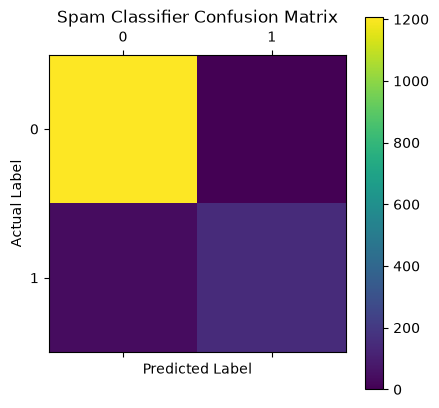

In [303]:
plt.matshow(cm)

plt.title("Spam Classifier Confusion Matrix")

plt.colorbar()

plt.ylabel("Actual Label")

plt.xlabel("Predicted Label")

plt.show()

In [304]:
cm

array([[1206,    0],
       [  39,  148]])

In [305]:
TN, FP, FN, TP = cm.ravel()

print("True Negatives :", TN)
print("False Positives:", FP)
print("False Negatives:", FN)
print("True Positives :", TP)

True Negatives : 1206
False Positives: 0
False Negatives: 39
True Positives : 148


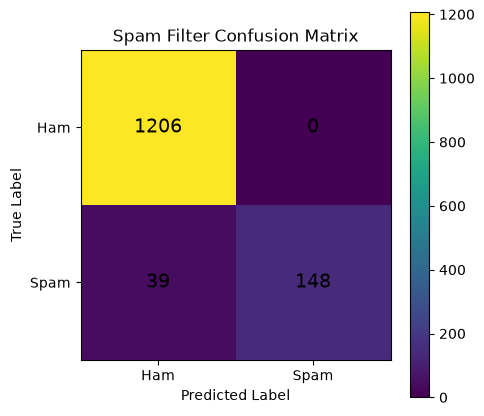

In [306]:
#advanced graphical representation of confusion matrix

plt.figure(figsize=(5,5))

plt.imshow(cm, interpolation="nearest")

plt.title("Spam Filter Confusion Matrix")

plt.colorbar()

plt.xticks([0,1], ["Ham","Spam"])
plt.yticks([0,1], ["Ham","Spam"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 fontsize=14)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [308]:
from sklearn.metrics import accuracy_score

In [309]:
print('Accuracy:', accuracy_score(y_test, predictions))


Accuracy: 0.9720028715003589
